✅ Bibliotecas carregadas com sucesso.
📅 Série gerada: 60 observações mensais
💰 Preço médio histórico: R$ 932.61/saca
📈 Preço máximo: R$ 1099.27 | Mínimo: R$ 804.85
📋 Primeiros registros da série:
🤖 Modelo treinado:
   Equação: Preço = 796.01 + 4.4786 × Mês
📐 Métricas de Avaliação do Modelo:
   R²   = 0.8917  → 89.2% da variância explicada pelo modelo
   MAE  = R$ 21.96  → erro médio absoluto por saca
   RMSE = R$ 27.03  → penaliza erros grandes
   Coeficiente angular: R$ 4.48/mês (tendência de alta)
   Intercepto: R$ 796.01
🔮 Projeção de Preços — Jan a Dez/2026:
       Mês  Previsão (R$)  IC 95% Inf.  IC 95% Sup.
2026-01-01    R$ 1,069.21  R$ 1,016.24  R$ 1,122.18
2026-02-01    R$ 1,073.69  R$ 1,020.72  R$ 1,126.65
2026-03-01    R$ 1,078.16  R$ 1,025.19  R$ 1,131.13
2026-04-01    R$ 1,082.64  R$ 1,029.67  R$ 1,135.61
2026-05-01    R$ 1,087.12  R$ 1,034.15  R$ 1,140.09
2026-06-01    R$ 1,091.60  R$ 1,038.63  R$ 1,144.57
2026-07-01    R$ 1,096.08  R$ 1,043.11  R$ 1,149.05
2026-08-01    R

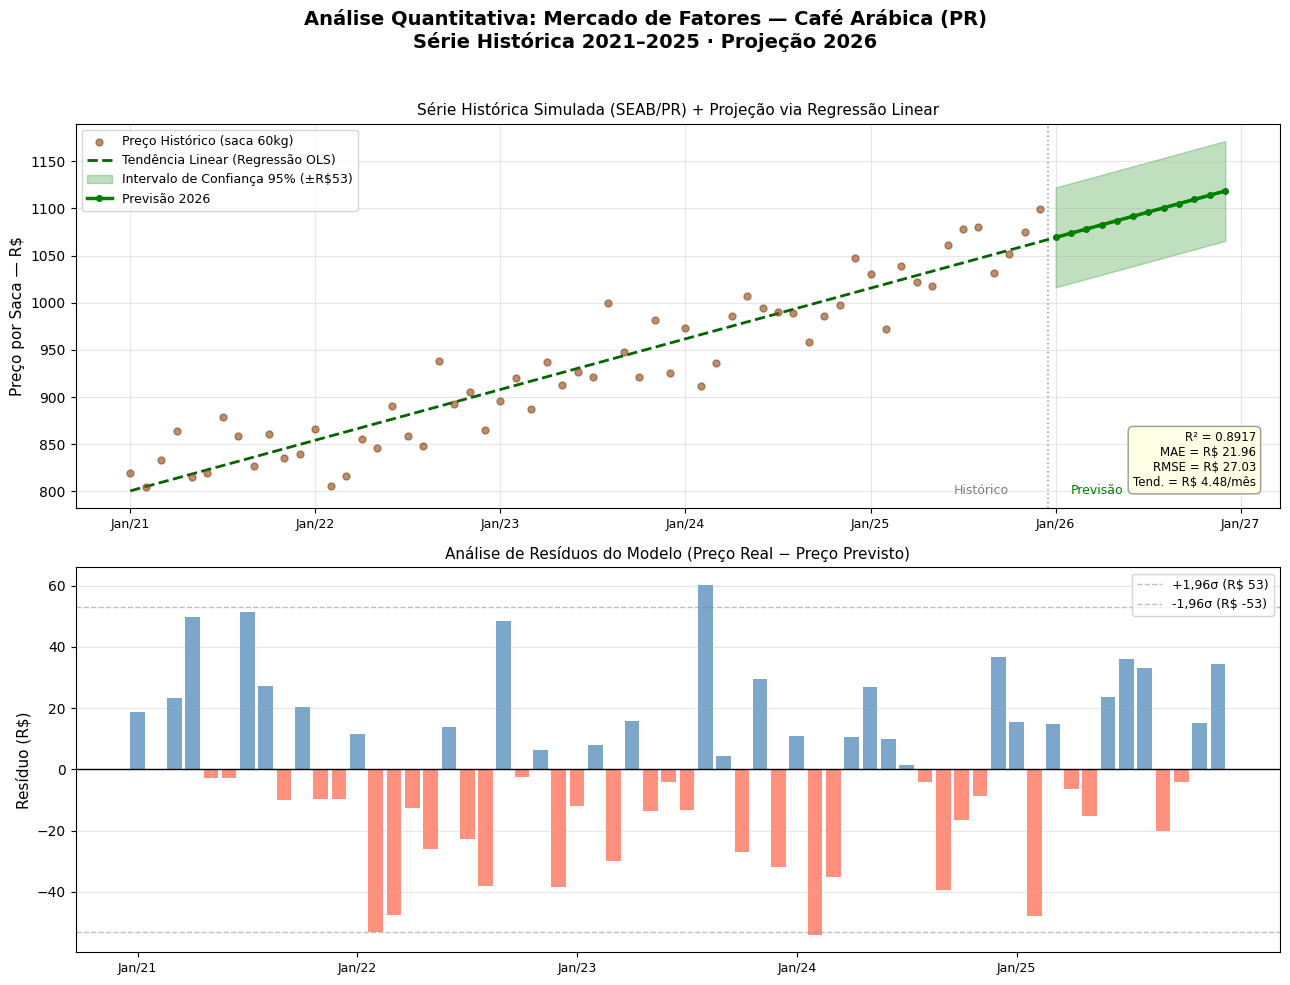

💾 Gráfico salvo em: serie_preditiva_cafe.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('✅ Bibliotecas carregadas com sucesso.')

def gerar_dados(n_meses=60, preco_base=800, tendencia=4.5, volatilidade=30, seed=42):
    """
    Gera série histórica simulada de preços do café (saca 60kg).

    Parâmetros:
    -----------
    n_meses     : número de meses da série histórica
    preco_base  : preço inicial em R$/saca
    tendencia   : variação mensal de tendência (R$/mês)
    volatilidade: desvio padrão do ruído de mercado
    seed        : semente para reprodutibilidade

    Retorna:
    --------
    meses  : array de índices mensais (1 a n_meses)
    precos : array de preços simulados
    """
    np.random.seed(seed)
    meses = np.arange(1, n_meses + 1).reshape(-1, 1)
    precos = preco_base + (meses * tendencia) + np.random.normal(0, volatilidade, size=(n_meses, 1))
    return meses, precos

meses, precos = gerar_dados()
print(f'📅 Série gerada: {len(meses)} observações mensais')
print(f'💰 Preço médio histórico: R$ {precos.mean():.2f}/saca')
print(f'📈 Preço máximo: R$ {precos.max():.2f} | Mínimo: R$ {precos.min():.2f}')

datas = pd.date_range(start='2021-01-01', periods=60, freq='MS')

df_historico = pd.DataFrame({
    'mes_idx': meses.flatten(),
    'data': datas,
    'preco_saca': precos.flatten()
})

print('📋 Primeiros registros da série:')
df_historico.head(6)

def treinar_modelo(meses, precos):
    """
    Treina modelo de regressão linear simples.
    Variável independente: índice do mês
    Variável dependente: preço da saca (R$)
    """
    modelo = LinearRegression()
    modelo.fit(meses, precos)
    return modelo

modelo = treinar_modelo(meses, precos)

print('🤖 Modelo treinado:')
print(f'   Equação: Preço = {modelo.intercept_[0]:.2f} + {modelo.coef_[0][0]:.4f} × Mês')

def avaliar_modelo(modelo, meses, precos):
    """
    Calcula métricas de desempenho do modelo.

    R²  : coeficiente de determinação (0 a 1, quanto maior melhor)
    MAE : erro absoluto médio em R$
    RMSE: raiz do erro quadrático médio em R$
    """
    y_pred = modelo.predict(meses)
    r2   = r2_score(precos, y_pred)
    mae  = mean_absolute_error(precos, y_pred)
    rmse = np.sqrt(mean_squared_error(precos, y_pred))
    residuos = precos.flatten() - y_pred.flatten()

    return {
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'residuos': residuos,
        'y_pred': y_pred
    }

metricas = avaliar_modelo(modelo, meses, precos)

print('📐 Métricas de Avaliação do Modelo:')
print(f'   R²   = {metricas["r2"]:.4f}  → {metricas["r2"]*100:.1f}% da variância explicada pelo modelo')
print(f'   MAE  = R$ {metricas["mae"]:.2f}  → erro médio absoluto por saca')
print(f'   RMSE = R$ {metricas["rmse"]:.2f}  → penaliza erros grandes')
print(f'   Coeficiente angular: R$ {modelo.coef_[0][0]:.2f}/mês (tendência de alta)')
print(f'   Intercepto: R$ {modelo.intercept_[0]:.2f}')

meses_futuros = np.arange(61, 73).reshape(-1, 1)
datas_futuras = pd.date_range(start='2026-01-01', periods=12, freq='MS')
previsao = modelo.predict(meses_futuros)

# Intervalo de confiança de 95% baseado nos resíduos históricos
std_residuos = metricas['residuos'].std()
margem_ic95 = 1.96 * std_residuos

df_previsao = pd.DataFrame({
    'data': datas_futuras,
    'previsao': previsao.flatten(),
    'limite_inferior': previsao.flatten() - margem_ic95,
    'limite_superior': previsao.flatten() + margem_ic95
})

print('🔮 Projeção de Preços — Jan a Dez/2026:')
print(df_previsao[['data','previsao','limite_inferior','limite_superior']]
      .rename(columns={'data':'Mês','previsao':'Previsão (R$)',
                       'limite_inferior':'IC 95% Inf.','limite_superior':'IC 95% Sup.'})
      .to_string(index=False, float_format='R$ {:,.2f}'.format))

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Análise Quantitativa: Mercado de Fatores — Café Arábica (PR)\nSérie Histórica 2021–2025 · Projeção 2026',
             fontsize=14, fontweight='bold', y=0.98)

# --- Gráfico 1: Série histórica + previsão + IC ---
ax1 = axes[0]

todos_meses = np.vstack((meses, meses_futuros))
tendencia_completa = modelo.predict(todos_meses)

ax1.scatter(meses.flatten(), precos.flatten(),
            color='saddlebrown', alpha=0.6, s=25, zorder=3, label='Preço Histórico (saca 60kg)')

ax1.plot(todos_meses.flatten(), tendencia_completa.flatten(),
         color='darkgreen', linestyle='--', linewidth=2, label='Tendência Linear (Regressão OLS)')

ax1.fill_between(meses_futuros.flatten(),
                 previsao.flatten() - margem_ic95,
                 previsao.flatten() + margem_ic95,
                 alpha=0.25, color='green', label=f'Intervalo de Confiança 95% (±R${margem_ic95:.0f})')

ax1.plot(meses_futuros.flatten(), previsao.flatten(),
         color='green', linewidth=2.5, marker='o', markersize=4, label='Previsão 2026')

# Linha divisória histórico / previsão
ax1.axvline(x=60.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax1.text(58, precos.min() * 0.99, 'Histórico', ha='right', color='gray', fontsize=9)
ax1.text(62, precos.min() * 0.99, 'Previsão', ha='left', color='green', fontsize=9)

# Rótulos de ano no eixo X
ticks_pos = [1, 13, 25, 37, 49, 61, 73]
ticks_lbl = ['Jan/21', 'Jan/22', 'Jan/23', 'Jan/24', 'Jan/25', 'Jan/26', 'Jan/27']
ax1.set_xticks(ticks_pos)
ax1.set_xticklabels(ticks_lbl, fontsize=9)

ax1.set_ylabel('Preço por Saca — R$', fontsize=11)
ax1.set_title('Série Histórica Simulada (SEAB/PR) + Projeção via Regressão Linear', fontsize=11)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# Caixa de métricas no gráfico
txt_metricas = (f"R² = {metricas['r2']:.4f}\n"
                f"MAE = R$ {metricas['mae']:.2f}\n"
                f"RMSE = R$ {metricas['rmse']:.2f}\n"
                f"Tend. = R$ {modelo.coef_[0][0]:.2f}/mês")
ax1.text(0.98, 0.05, txt_metricas, transform=ax1.transAxes,
         fontsize=8.5, va='bottom', ha='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# --- Gráfico 2: Análise de Resíduos ---
ax2 = axes[1]
ax2.bar(meses.flatten(), metricas['residuos'],
        color=np.where(metricas['residuos'] >= 0, 'steelblue', 'tomato'),
        alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(margem_ic95, color='gray', linewidth=1, linestyle='--', alpha=0.5, label=f'+1,96σ (R$ {margem_ic95:.0f})')
ax2.axhline(-margem_ic95, color='gray', linewidth=1, linestyle='--', alpha=0.5, label=f'-1,96σ (R$ {-margem_ic95:.0f})')

ax2.set_xticks([1, 13, 25, 37, 49])
ax2.set_xticklabels(['Jan/21', 'Jan/22', 'Jan/23', 'Jan/24', 'Jan/25'], fontsize=9)
ax2.set_ylabel('Resíduo (R$)', fontsize=11)
ax2.set_title('Análise de Resíduos do Modelo (Preço Real − Preço Previsto)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('serie_preditiva_cafe.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráfico salvo em: serie_preditiva_cafe.png')

